In [2]:
import pandas as pd
import numpy as np

In [4]:
import pandas as pd

test_file = "cyclistic_project/Data/Raw/202509-divvy-tripdata.csv"
df_test = pd.read_csv(test_file, engine='python', on_bad_lines='skip')
print("read：", len(df_test))

read： 714759


In [5]:
import glob
import os
import pandas as pd

file_pattern = "cyclistic_project/Data/Raw/*-divvy-tripdata.csv"
files = sorted(glob.glob(file_pattern))

print(f"found {len(files)} month files：")
for f in files:
    print(f" - {os.path.basename(f)}")

if len(files) > 0:
    df_list = []
    for f in files:
        print(f"reading: {os.path.basename(f)}...")
        temp_df = pd.read_csv(f, engine='python', on_bad_lines='skip')
        df_list.append(temp_df)
    
    df = pd.concat(df_list, ignore_index=True)
    
    print("\nMerge completed")
    print("Rows:", len(df))
    print("Columns:", df.shape[1])
else:
    print("No matching files found. Please verify the path and file name.")

found 12 month files：
 - 202509-divvy-tripdata.csv
 - 202510-divvy-tripdata.csv
 - 202511-divvy-tripdata.csv
 - 202512-divvy-tripdata.csv
 - 202601-divvy-tripdata.csv
 - 202602-divvy-tripdata.csv
 - 202603-divvy-tripdata.csv
 - 202604-divvy-tripdata.csv
 - 202605-divvy-tripdata.csv
 - 202606-divvy-tripdata.csv
 - 202607-divvy-tripdata.csv
 - 202608-divvy-tripdata.csv
reading: 202509-divvy-tripdata.csv...
reading: 202510-divvy-tripdata.csv...
reading: 202511-divvy-tripdata.csv...
reading: 202512-divvy-tripdata.csv...
reading: 202601-divvy-tripdata.csv...
reading: 202602-divvy-tripdata.csv...
reading: 202603-divvy-tripdata.csv...
reading: 202604-divvy-tripdata.csv...
reading: 202605-divvy-tripdata.csv...
reading: 202606-divvy-tripdata.csv...
reading: 202607-divvy-tripdata.csv...
reading: 202608-divvy-tripdata.csv...

Merge completed
Rows: 6115982
Columns: 13


In [6]:
print(df.columns.tolist())

['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [7]:
df.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1285406
start_station_id      1285406
end_station_name      1349937
end_station_id        1349937
start_lat                   0
start_lng                   0
end_lat                  5426
end_lng                  5426
member_casual               0
dtype: int64

In [8]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [9]:
print(df['member_casual'].value_counts())
print(df['rideable_type'].value_counts())

member    3955617
casual    2160365
Name: member_casual, dtype: int64
electric_bike    4282145
classic_bike     1833837
Name: rideable_type, dtype: int64


In [10]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

print(df[['started_at', 'ended_at']].dtypes)

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [12]:
df['ride_length'] = (df['ended_at']- df['started_at']).dt.total_seconds() / 60
df['day_of_week'] = df['started_at'].dt.dayofweek.apply(lambda x: (x+1) % 7 + 1)
df['day_name'] = df['started_at'].dt.day_name()

In [13]:
df[['started_at', 'ended_at', 'ride_length', 'day_of_week', 'day_name']].head()

,started_at,ended_at,ride_length,day_of_week,day_name
0,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,20.099167,2,Monday
1,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,7.974217,2,Monday
2,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,23.631833,2,Monday
3,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,17.528800,2,Monday
4,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,15.520350,6,Friday


In [14]:
print("Negative count:", (df['ride_length'] <= 0).sum())
print("over 24 hours(1440 min) count:", (df['ride_length'] > 1440).sum())
print(df['ride_length'].describe())

Negative count: 29
over 24 hours(1440 min) count: 5309
count    6.115982e+06
mean     1.531125e+01
std      5.150110e+01
min     -5.479480e+01
25%      5.330050e+00
50%      9.263300e+00
75%      1.615778e+01
max      1.559950e+03
Name: ride_length, dtype: float64


In [17]:
df_clean = df[(df['ride_length'] > 0) & (df['ride_length'] <= 1440)].copy()

print(f"original: {len(df):,}")
print(f"new: {len(df_clean):,}")
print(f"cleaned: {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.3f}%)")

original: 6,115,982
new: 6,110,644
cleaned: 5,338 (0.087%)


In [18]:
df_clean.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'count'])

,mean,median,max,count
member_casual,,,,
casual,17.789128,10.842033,1439.975950,2156112
member,11.968488,8.550617,1439.901683,3954532


In [19]:
df_clean.groupby(['member_casual', 'day_name'])['ride_length'].agg(['mean', 'count'])

mean   count
member_casual day_name                    
casual        Friday     17.466359  333938
              Monday     17.974612  257401
              Saturday   20.081145  455707
              Sunday     20.490318  347565
              Thursday   15.404535  267561
              Tuesday    15.576544  246448
              Wednesday  14.799233  247492
member        Friday     11.902252  577780
              Monday     11.694511  566006
              Saturday   13.177004  502620
              Sunday     13.051433  420215
              Thursday   11.497074  625340
              Tuesday    11.567918  630785
              Wednesday  11.459320  631786

In [30]:
df_clean.groupby(['member_casual', 'rideable_type']).size().unstack()


rideable_type,classic_bike,electric_bike
member_casual,,
casual,452940,1117331
member,1065198,2063717


In [20]:
df[df['start_station_name'].isnull()]['rideable_type'].value_counts()
df['rideable_type'].value_counts()

electric_bike    4282145
classic_bike     1833837
Name: rideable_type, dtype: int64

In [32]:
missing_station = df[df['start_station_name'].isnull()]['rideable_type'].value_counts(normalize=True) * 100
overall = df['rideable_type'].value_counts(normalize=True) * 100

print("miss station name bike percentage:")
print(missing_station)
print("\nwhole bike percentage:")
print(overall)

miss station name bike percentage:
electric_bike    100.0
Name: rideable_type, dtype: float64

whole bike percentage:
electric_bike    67.648252
classic_bike     32.351748
Name: rideable_type, dtype: float64


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

colors = {'member': '#1f77b4', 'casual': '#ff7f0e'}

Matplotlib is building the font cache; this may take a moment.


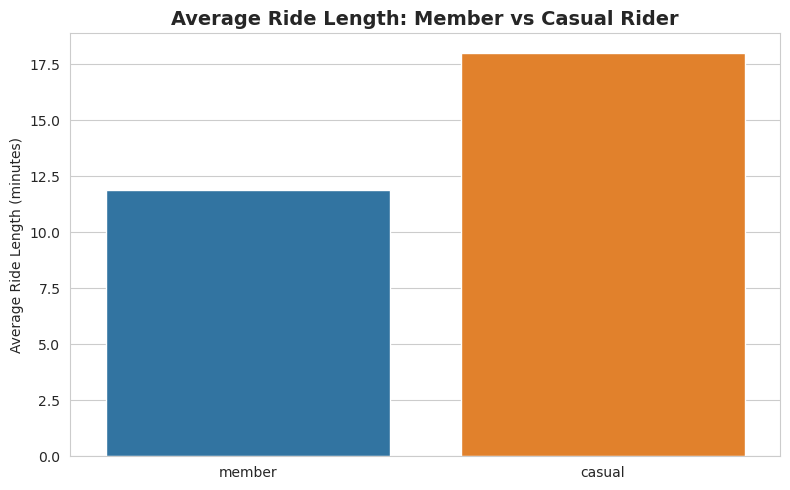

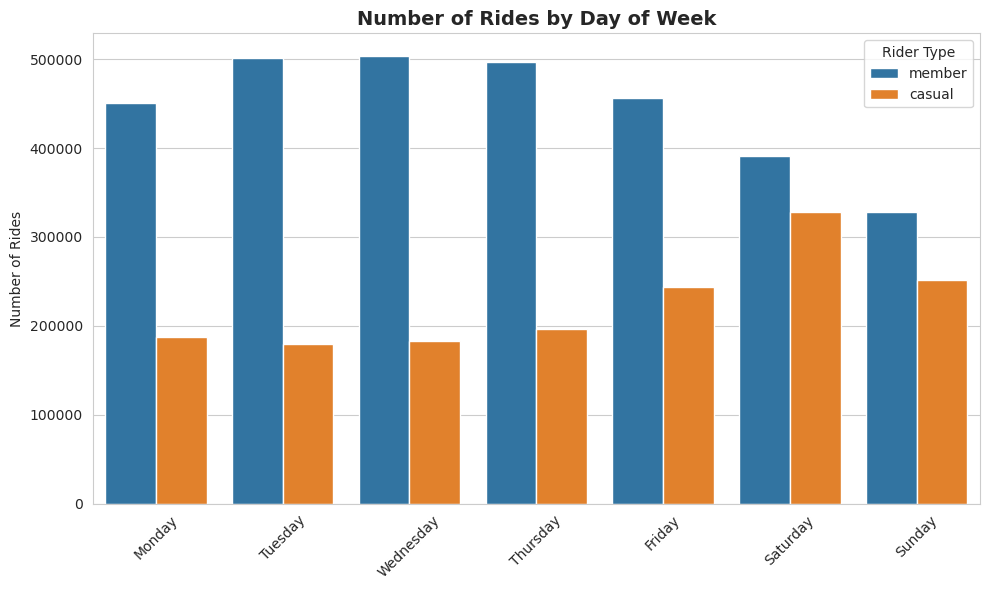

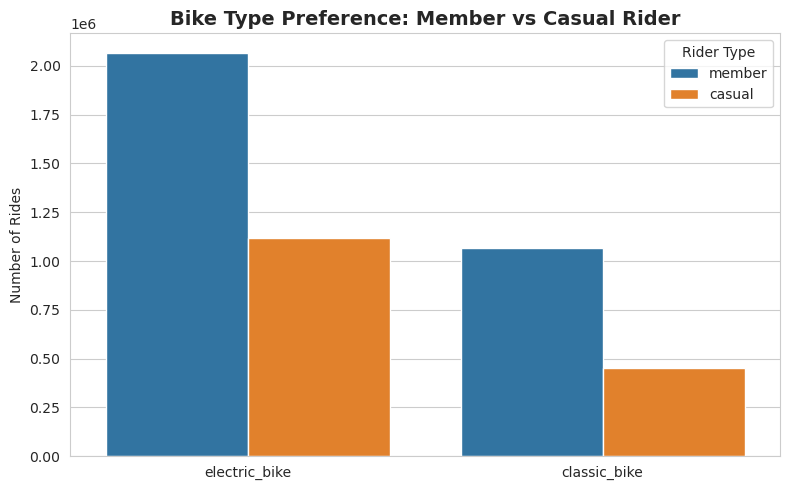

In [40]:
import os
os.makedirs('outputs', exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_clean, x='member_casual', y='ride_length', 
            palette=colors, ax=ax, ci=None)
ax.set_title('Average Ride Length: Member vs Casual Rider', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Average Ride Length (minutes)')
plt.tight_layout()
plt.savefig('outputs/ride_length_comparison.png', dpi=150)
plt.show()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_clean, x='day_name', hue='member_casual', 
              order=day_order, palette=colors, ax=ax)
ax.set_title('Number of Rides by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Rides')
ax.legend(title='Rider Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/rides_by_day.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_clean, x='rideable_type', hue='member_casual', 
              palette=colors, ax=ax)
ax.set_title('Bike Type Preference: Member vs Casual Rider', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Rides')
ax.legend(title='Rider Type')
plt.tight_layout()
plt.savefig('outputs/bike_type_preference.png', dpi=150)
plt.show()

In [41]:
df_clean['month'] = df_clean['started_at'].dt.month_name()
df_clean['month_num'] = df_clean['started_at'].dt.month 

monthly = df_clean.groupby(['month_num', 'month', 'member_casual']).size().reset_index(name='ride_count')
monthly = monthly.sort_values('month_num')
monthly

,month_num,month,member_casual,ride_count
0,1,January,casual,24656
1,1,January,member,112933
2,2,February,casual,41088
3,2,February,member,160251
4,3,March,casual,87631
5,3,March,member,229121
6,4,April,casual,131229
7,4,April,member,316693
8,5,May,casual,196629
9,5,May,member,329391


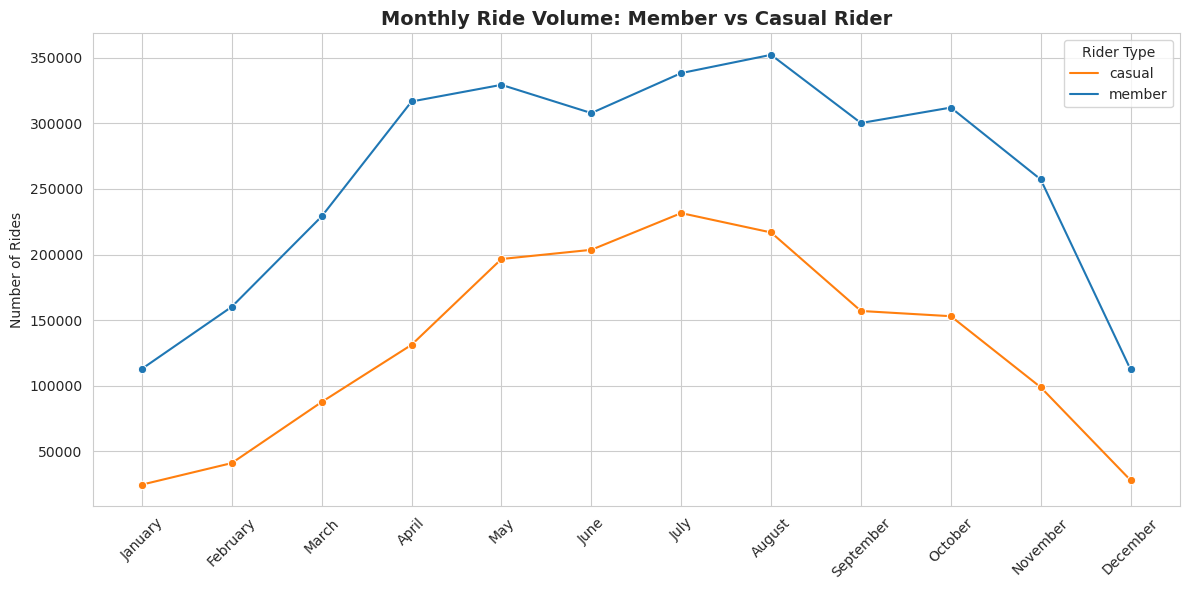

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='ride_count', hue='member_casual', 
             palette=colors, marker='o', ax=ax,
             sort=False) 
ax.set_title('Monthly Ride Volume: Member vs Casual Rider', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Rides')
ax.legend(title='Rider Type')
plt.xticks(rotation=45)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/monthly_trend.png', dpi=150)
plt.show()